## 0. Importação e Análise do Dataset

Fonte do Dataset: [SDSS DR19 Updated 2025: Star / Galaxy / Qso](https://www.kaggle.com/datasets/diegovillagranc/sdss19-stellar-classification-star-galaxy-qso?select=sdss19_imbalanced.csv) por **Diego Villagrán** no Kaggle,

Que é uma versão atualizada e melhorada de: [Stellar Classification Dataset - SDSS17](https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17/data) por **fedesoriano** no Kaggle,

Cuja fonte de dados foi de: [SDSS Data Release 19](https://skyserver.sdss.org/dr19)

Descrição das Colunas provida pelo dataset do Kaggle:

Coluna | Descrição
--- | ---
obj_class | spectroscopic classification (GALAXY, STAR, QSO)
ra | Right ascension in degrees (J2000, ICRS)
dec | Declination in degrees (J2000, ICRS)
u | PSF magnitude in u-band (ultraviolet, 354nm)
g | PSF magnitude in g-band (green, 477nm)
r | PSF magnitude in r-band (red, 623nm)
i | PSF magnitude in i-band (near-infrared, 763nm)
zband | PSF magnitude in z-band (infrared, 913nm)
petroR50_r | Petrosian radius containing 50% of flux in r-band (arcsec) — proxy for object size
extinction_r | Milky Way dust extinction in r-band (magnitudes) — use to correct: r_corr = r - extinction_r
pmRa | Proper motion in RA direction (mas/yr)
pmDec | Proper motion in Dec direction (mas/yr)
pmRaErr | Proper motion error in RA (mas/yr)
pmDecErr | Proper motion error in Dec (mas/yr)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Importando dataset do Kaggle
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "diegovillagranc/sdss19-stellar-classification-star-galaxy-qso",
  "sdss19_imbalanced.csv",
)
df

,obj_class,ra,dec,u,g,r,i,zband,petroR50_r,extinction_r,pmRa,pmDec,pmRaErr,pmDecErr
0,STAR,94.151185,0.556955,18.55815,17.13832,16.46642,16.17820,16.00801,0.616056,0.971888,2.823026,2.655500,3.005414,3.005414
1,STAR,94.162827,0.595549,18.19262,17.05079,16.95350,16.97508,16.99701,0.633574,0.982412,4.386912,2.636851,3.002324,3.002324
2,STAR,94.193505,0.545911,17.16965,15.73020,15.58151,15.56168,15.50965,0.631930,0.976873,1.592040,-2.781029,2.939655,2.939655
3,STAR,94.243501,0.447088,17.21898,16.08286,16.01093,16.03192,16.02211,0.613530,0.955022,2.372745,1.497425,2.941542,2.941542
4,STAR,94.312293,0.487440,16.75434,15.33976,15.09668,15.02321,14.91764,0.634270,0.975247,1.869048,2.719901,2.939654,2.939654
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279997,GALAXY,205.635560,3.082127,17.44481,15.99625,15.47226,15.19528,14.98716,5.335046,0.055828,24.441260,5.196535,2.561155,2.561155
279998,STAR,205.677580,3.039798,20.10751,19.15912,18.83749,18.71170,18.65036,0.629756,0.054367,-4.931767,-3.462556,3.518237,3.518237
279999,GALAXY,205.765360,3.031234,20.54722,18.40636,17.20650,16.69568,16.28923,1.972270,0.055669,2.367301,2.342535,2.751652,2.751652
280000,GALAXY,205.655588,3.064547,22.36661,20.88627,19.19122,18.54666,18.15465,1.500211,0.054942,-7.516692,-5.082550,4.913247,4.913247


In [3]:
df.describe()

,ra,dec,u,g,r,i,zband,petroR50_r,extinction_r,pmRa,pmDec,pmRaErr,pmDecErr
count,280002.000000,280002.000000,280002.000000,280002.000000,280002.000000,280002.000000,280002.000000,280002.000000,280002.000000,280002.000000,280002.000000,280002.000000,280002.000000
mean,165.950152,22.730146,21.432372,19.845792,18.885888,18.386532,18.106354,1.503447,0.098359,-0.507517,-0.912034,2.771366,2.771366
std,66.259977,27.135085,2.267683,1.931811,1.712333,1.625857,1.641316,1.664955,0.191333,8.154989,8.353731,2.540176,2.540176
min,0.004289,-11.244273,11.960910,11.840130,11.629170,11.051390,10.616260,0.115081,0.008580,-56.995480,-56.995620,0.000000,0.000000
25%,129.205036,-0.242879,19.665615,18.251315,17.465460,17.063038,16.780700,0.709724,0.051280,-2.373086,-2.837724,0.000000,0.000000
50%,163.284179,3.078136,21.239290,20.030490,19.097320,18.618320,18.281125,1.229612,0.077344,0.000000,0.000000,3.024227,3.024227
75%,206.555414,51.996310,23.071347,21.534945,20.418405,19.647187,19.256105,1.872871,0.111708,1.687489,1.344996,3.879420,3.879420
max,359.997379,68.739531,31.143020,27.851710,30.037920,30.028860,28.234510,223.407400,34.052850,56.858720,56.941540,191.487700,191.487700


In [4]:
print("Checando por valores nulos:")
df.isna().sum().sort_values(ascending=False)

Checando por valores nulos:


obj_class       0
ra              0
dec             0
u               0
g               0
r               0
i               0
zband           0
petroR50_r      0
extinction_r    0
pmRa            0
pmDec           0
pmRaErr         0
pmDecErr        0
dtype: int64

In [5]:
print("Checando tipos de dados:")
df.dtypes

Checando tipos de dados:


obj_class        object
ra              float64
dec             float64
u               float64
g               float64
r               float64
i               float64
zband           float64
petroR50_r      float64
extinction_r    float64
pmRa            float64
pmDec           float64
pmRaErr         float64
pmDecErr        float64
dtype: object

In [6]:
print("Listando valores de obj_class")
df["obj_class"].value_counts()

Listando valores de obj_class


obj_class
GALAXY    167343
STAR       70649
QSO        42010
Name: count, dtype: int64

---

## 1. Preparação e Engenharia de Features: Análise Exploratória e Criação de Novas Variáveis

In [7]:
df_main = df.copy()

# Calculando coluna `r_corr` como descrito pela fonte:
# r_corr = r - extinction_r
df_main["r_corr"] = df_main["r"] - df_main["extinction_r"]

# Criando features de cor secundárias a partir das magnitudes.
# Estas features são definidas pela diferença de magnitude entre bandas adjacentes.
# As diferenças entre as magnitudes quantificam melhor a "tonalidade" de um objeto,
# que é um indicafor físico mais robusto do que magnitudes isoladas,
# que podem ser afetadas por fatores como distância e extinção.
df_main["u_g"] = df_main["u"] - df_main["g"]
df_main["g_r"] = df_main["g"] - df_main["r_corr"]
df_main["r_i"] = df_main["r_corr"] - df_main["i"]
df_main["i_z"] = df_main["i"] - df_main["zband"]

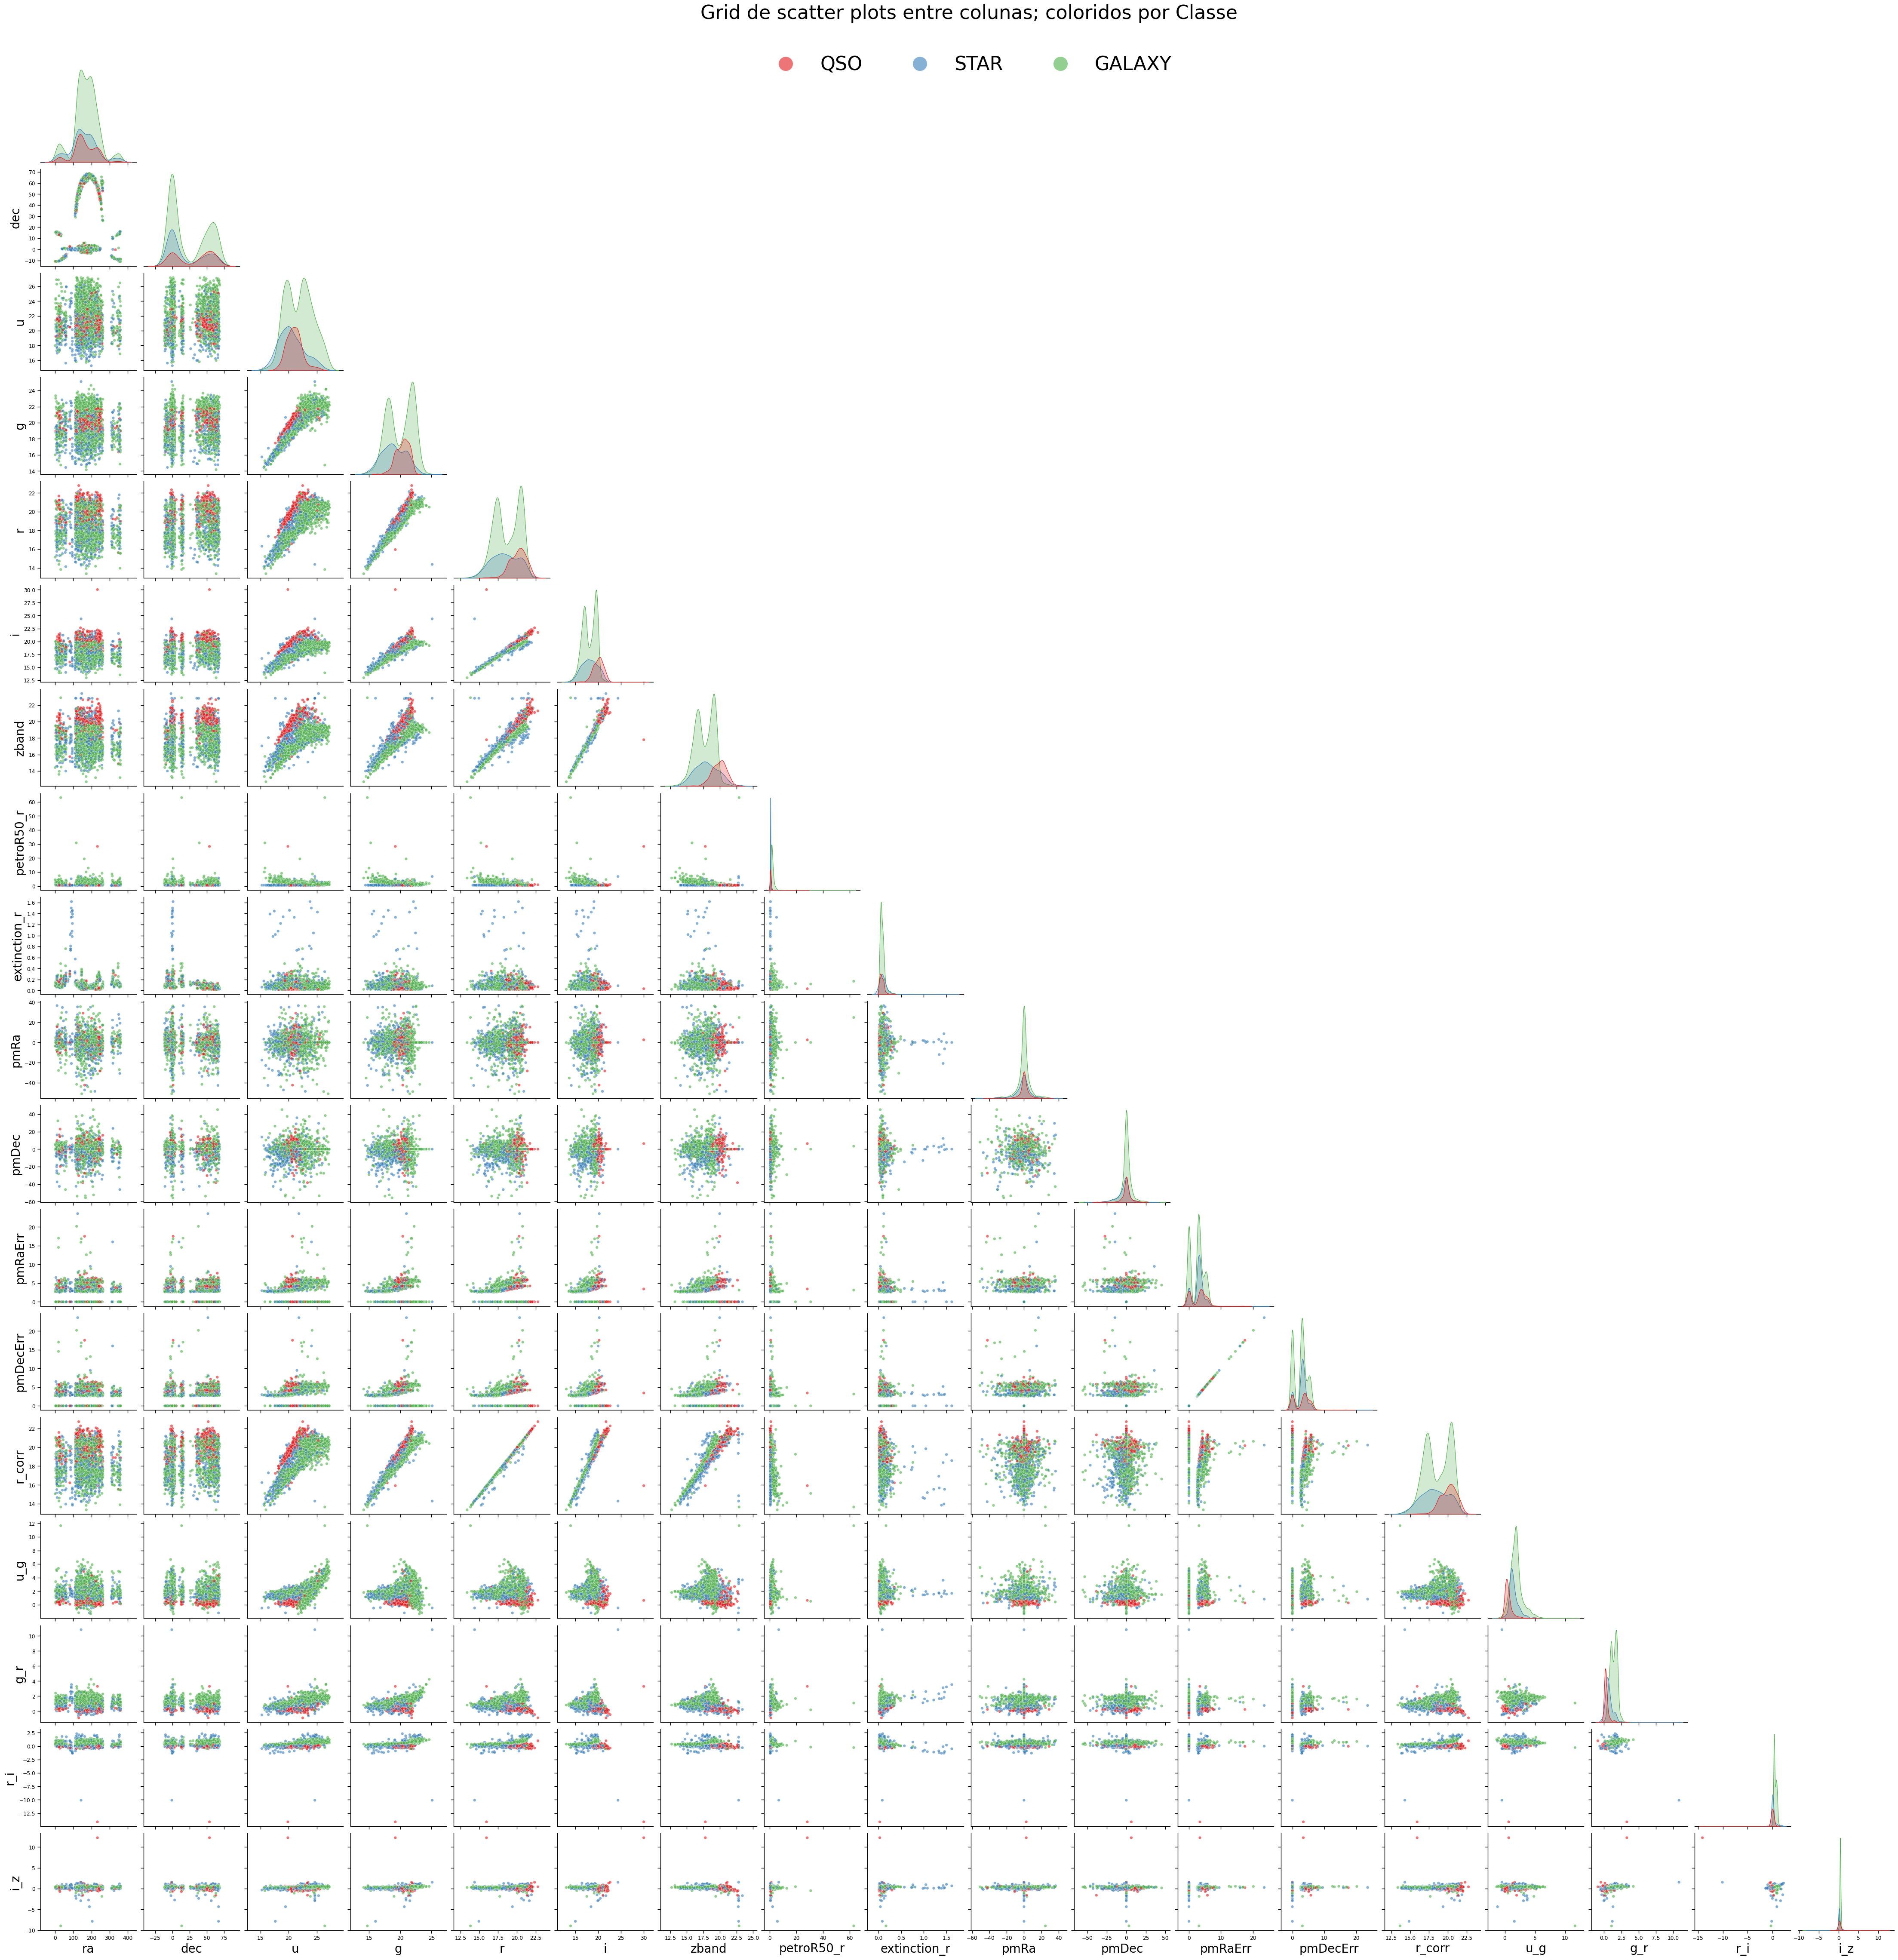

In [8]:
# Preparando um Pairplot para observar relações entre features referentes à classe
df_pairplot = df_main.sample(2500, random_state=42)

# https://stackoverflow.com/a/45216797
sns.set_context("paper", rc={"axes.labelsize": 20})

ax = sns.pairplot(
    df_pairplot,
    hue='obj_class',
    palette='Set1',
    diag_kind='kde',
    plot_kws={'alpha':0.6},
    corner=True,
)
sns.set_context("paper", rc={"axes.labelsize": 12})

sns.move_legend(
    ax, "lower center", title=None,
    bbox_to_anchor=(0.5, 0.975), ncol=3, frameon=False,
    fontsize=32, markerscale=5
)
plt.suptitle('Grid de scatter plots entre colunas; coloridos por Classe', y=1.02, fontsize=32)
plt.show()

O gráfico `ra` x `dec` tem um formato interessante - Vamos visualizar.

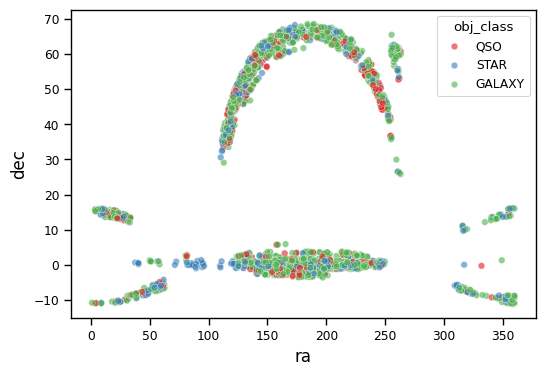

In [9]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=df_pairplot,
    x="ra",
    y="dec",
    hue="obj_class",
    palette='Set1',
    alpha=0.6,
);

Declination (dec) e Right Ascension (ra) são as coordenadas celestes usadas para localizar objetos no céu.

A relação entre os dois valores é direta, mas por que será que esse formato se manifestou?

---

## 2. Estudo dos dados: Clusterização e Comparação de Modelos (K-Means e AutoML)

O objetivo é avaliar se o K-Means, treinado **apenas** nas magnitudes `u` (UV) e `zband` (IR), 
consegue reproduzir as três classes astronômicas reais (GALAXY, STAR, QSO). 
A análise é dividida em etapas: scatter comparativo e métricas de alinhamento.

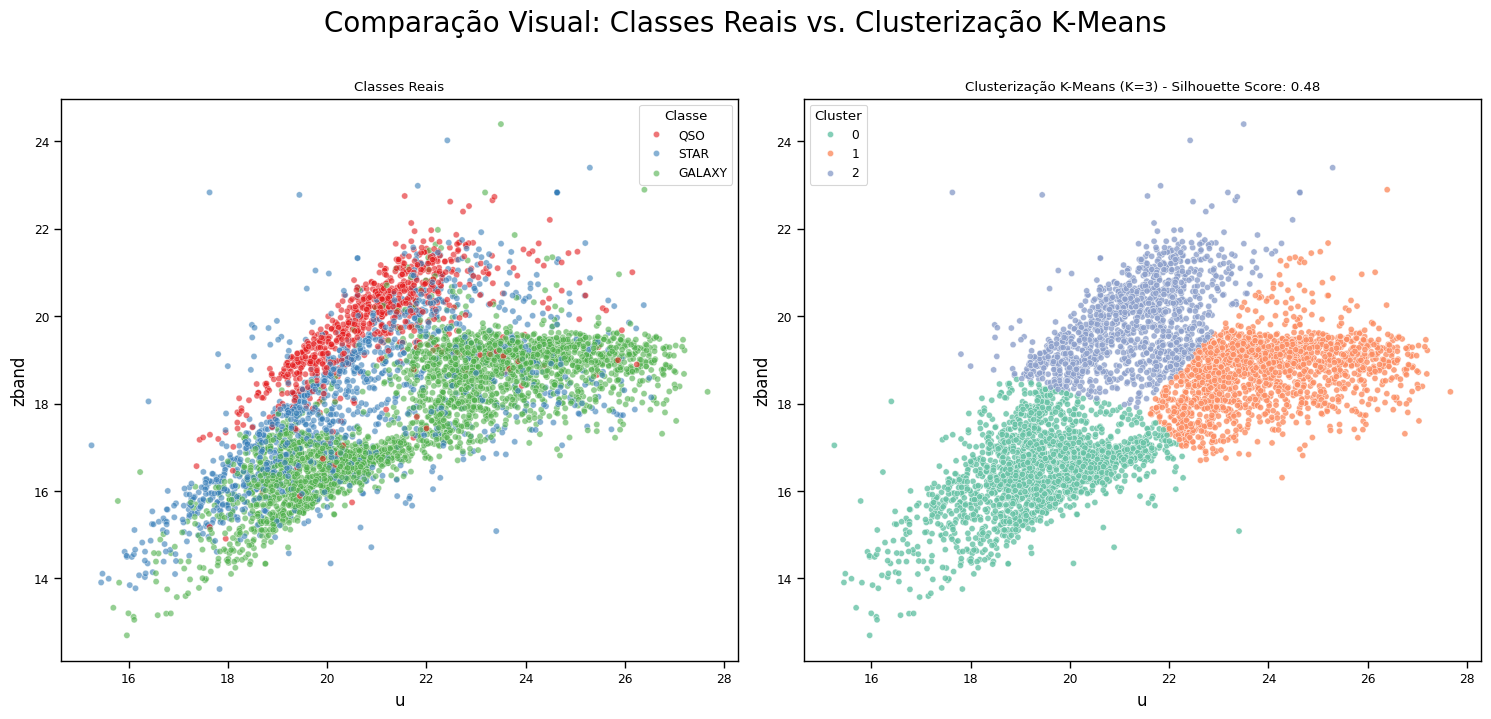

In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 0. Amostragem para reduzir o tempo de execução e evitar sobrecarga visual
df_clustering = df_main.sample(5000, random_state=42)

# 1. Selecionar features e target
X_features = df_clustering[['u', 'zband']]

y_true = df_clustering['obj_class']

# 2. Escalonar os dados (necessário para K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# 3. Aplicar K-Means com K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clustering['cluster'] = kmeans.fit_predict(X_scaled)

# 4. Calcular o Silhouette Score
# O silhouette score mede quão bem os pontos estão agrupados em relação aos clusters vizinhos.
silhouette_avg = silhouette_score(X_scaled, df_clustering['cluster'])

plt.figure(figsize=(15, 7))

# Plot 1: Comparação com Classes Reais (obj_class)
ax1 = sns.scatterplot(
    data=df_clustering,
    x='u',
    y='zband',
    hue='obj_class', # colorir pela classe real
    palette='Set1',
    alpha=0.6,
    s=20,
    ax=plt.subplot(1, 2, 1)
)
ax1.set_title('Classes Reais')
ax1.legend(title='Classe', loc='upper right')

# Plot 2: Clusterização K-Means (cluster)
ax2 = sns.scatterplot(
    data=df_clustering,
    x='u',
    y='zband',
    hue='cluster', # colorir pelo cluster predito
    palette='Set2',
    alpha=0.8,
    s=20,
    ax=plt.subplot(1, 2, 2)
)

ax2.set_title(f'Clusterização K-Means (K=3) - Silhouette Score: {silhouette_avg:.2f}')
ax2.legend(title='Cluster', loc='upper left')

plt.suptitle('Comparação Visual: Classes Reais vs. Clusterização K-Means', y=1.02, fontsize=20)
plt.tight_layout()
plt.show()

---

## 3. Seleção de Modelo com AutoML (PyCaret)

In [11]:
from pycaret.classification import ClassificationExperiment

exp = ClassificationExperiment()
exp.setup(
    data=df_main.sample(2000, random_state=42), # pegando uma amostra de 2k para acelerar o processo
    target='obj_class',
    session_id=42,
    train_size=0.7,
    normalize=True,
    normalize_method='robust',
    fold=20,
    verbose=True
)

# Comparar Modelos
best_model = exp.compare_models()

# Ver leaderboard completo
leaderboard = exp.pull()
leaderboard.head(10)

print("Best Model:")
best_model # xgboost!

,Description,Value
0,Session id,42
1,Target,obj_class
2,Target type,Multiclass
3,Target mapping,"GALAXY: 0, QSO: 1, STAR: 2"
4,Original data shape,"(2000, 19)"
5,Transformed data shape,"(2000, 19)"
6,Transformed train set shape,"(1400, 19)"
7,Transformed test set shape,"(600, 19)"
8,Numeric features,18
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.9379,0.9852,0.9379,0.9396,0.9371,0.8859,0.8874,0.0505
lightgbm,Light Gradient Boosting Machine,0.9350,0.9850,0.9350,0.9369,0.9339,0.8805,0.8822,0.1010
rf,Random Forest Classifier,0.9343,0.9834,0.9343,0.9366,0.9336,0.8795,0.8811,0.0235
gbc,Gradient Boosting Classifier,0.9307,0.0000,0.9307,0.9319,0.9298,0.8730,0.8744,0.0985
et,Extra Trees Classifier,0.9179,0.9769,0.9179,0.9202,0.9161,0.8480,0.8510,0.0130
lr,Logistic Regression,0.9000,0.0000,0.9000,0.9016,0.8992,0.8169,0.8185,0.1400
dt,Decision Tree Classifier,0.8979,0.9169,0.8979,0.9028,0.8979,0.8139,0.8162,0.0035
ada,Ada Boost Classifier,0.8936,0.0000,0.8936,0.8967,0.8927,0.8058,0.8078,0.0115
svm,SVM - Linear Kernel,0.8786,0.0000,0.8786,0.8838,0.8776,0.7783,0.7815,0.0035
knn,K Neighbors Classifier,0.8607,0.9418,0.8607,0.8617,0.8563,0.7392,0.7439,0.0740


Best Model:


XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cpu', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=-1, num_parallel_tree=None, ...)

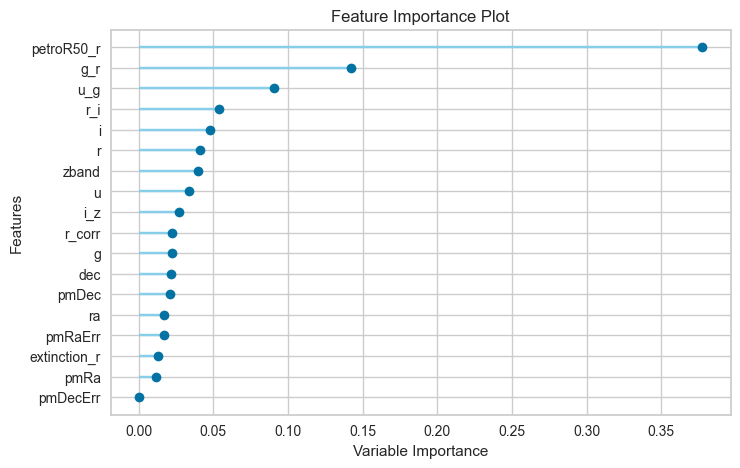

In [12]:
# achando features mais importantes
exp.plot_model(best_model, plot="feature_all")
# pmDecErr não contribui em nada!

---

## 4. Pipeline Completo de Classificação: Treinamento e Avaliação do Modelo XGBoost

In [13]:
# removendo features que não contribuem para o modelo
df_pipeline = df_main.copy().drop(columns=["pmDecErr", "pmRaErr"])

# separando features e target
X = df_pipeline.drop(columns=["obj_class"])
y = df_pipeline["obj_class"]

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode the target variable 'y' (obj_class)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (224001, 16)
Test shape: (56001, 16)


In [15]:
modelo_xgb = xgboost.XGBClassifier(n_estimators=2000, max_depth=4, learning_rate=0.3, random_state=42)

modelo_xgb.fit(X_train, y_train)

ypred_train = modelo_xgb.predict(X_train)
ypred_test = modelo_xgb.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score, classification_report, r2_score

# avaliação do modelo de classificação
accuracy_train = accuracy_score(y_train, ypred_train)
accuracy_test = accuracy_score(y_test, ypred_test)

print(f"Acurácia Treino: {accuracy_train:.4f}")
print(f"Acurácia Teste: {accuracy_test:.4f}")

# avaliação r2
r2_treino = r2_score(y_train, ypred_train)
r2_teste = r2_score(y_test, ypred_test)

print(f"R2 Treino: {r2_treino:.04f}")
print(f"R2 Teste: {r2_teste:.04f}")

# relatório de classificação
report_train = classification_report(y_train, ypred_train, target_names=le.classes_, output_dict=True)
report_test = classification_report(y_test, ypred_test, target_names=le.classes_, output_dict=True)

print("Relatório de Classificação (Treino):")
print(classification_report(y_train, ypred_train, target_names=le.classes_))
print("Relatório de Classificação (Teste):")
print(classification_report(y_test, ypred_test, target_names=le.classes_))

Acurácia Treino: 0.9945
Acurácia Teste: 0.9551
R2 Treino: 0.9861
R2 Teste: 0.8903
Relatório de Classificação (Treino):
              precision    recall  f1-score   support

      GALAXY       1.00      1.00      1.00    133874
         QSO       0.99      0.99      0.99     33608
        STAR       0.99      0.99      0.99     56519

    accuracy                           0.99    224001
   macro avg       0.99      0.99      0.99    224001
weighted avg       0.99      0.99      0.99    224001

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98     33469
         QSO       0.89      0.88      0.89      8402
        STAR       0.94      0.93      0.94     14130

    accuracy                           0.96     56001
   macro avg       0.94      0.93      0.93     56001
weighted avg       0.95      0.96      0.95     56001



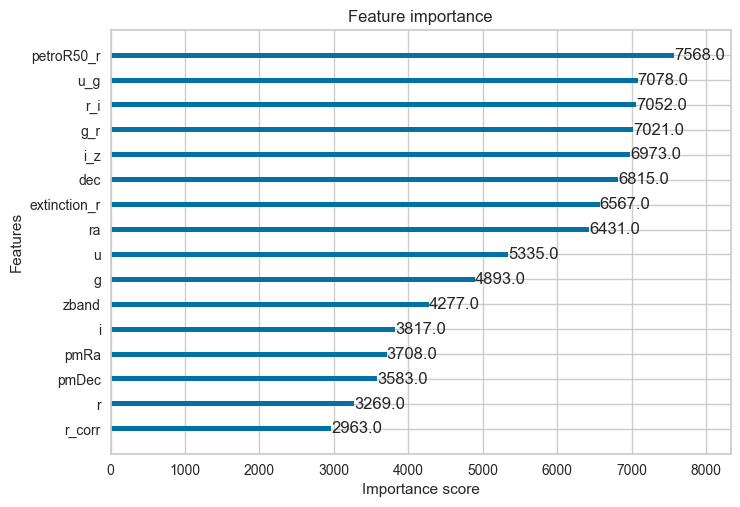

In [17]:
# plotando importância das features
xgboost.plot_importance(modelo_xgb);

---

## 5. Análise da Matriz de Confusão

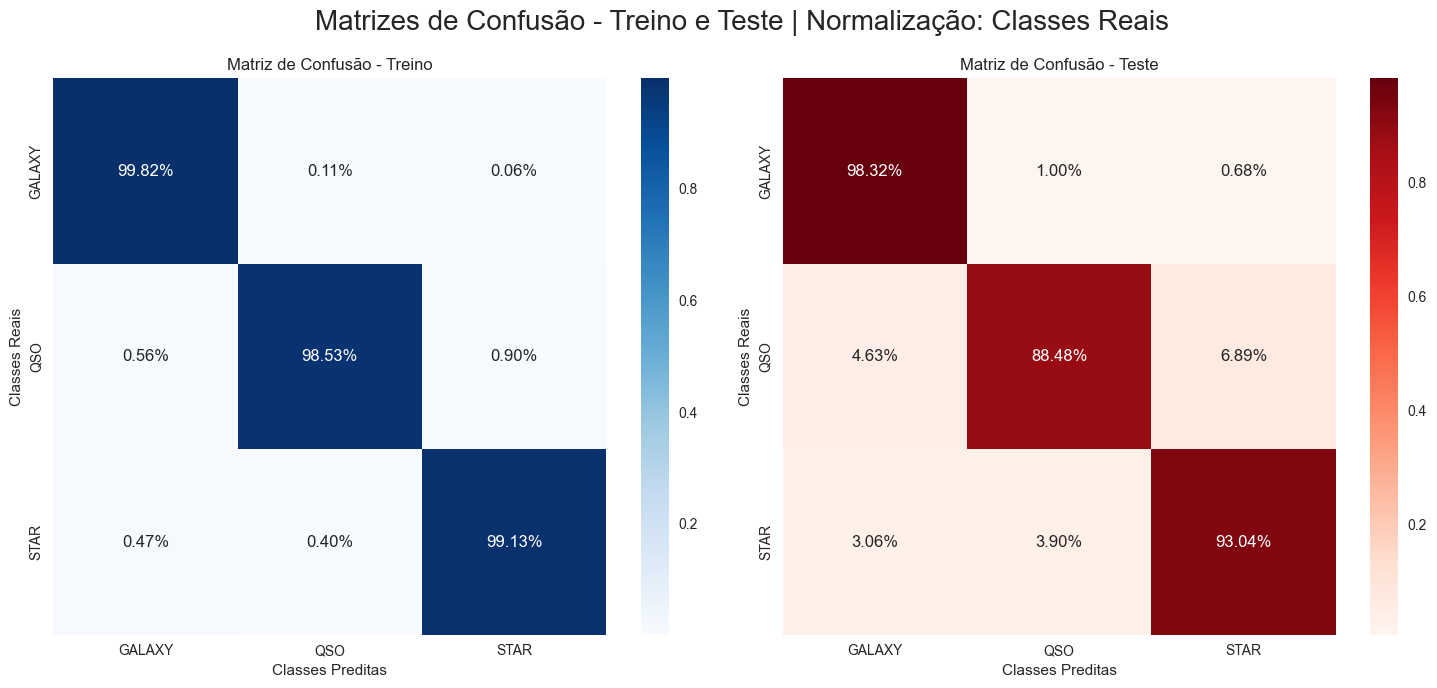

In [18]:
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(15, 7))

# Como a taxa de incidência de cada classe é diferente,
# é interessante normalizar a matriz de confusão para facilitar a interpretação.
CM_NORMALIZATION = 'true'  # None | 'true' | 'pred' | 'all'

# Matriz de Confusão para o conjunto de Treino
cm_train = confusion_matrix(y_train, ypred_train, normalize=CM_NORMALIZATION)

# Visualização da Matriz de Confusão de Treino
plt.subplot(1, 2, 1)
sns.heatmap(cm_train, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão - Treino')
plt.xlabel('Classes Preditas')
plt.ylabel('Classes Reais')

# Matriz de Confusão para o conjunto de Teste
cm_test = confusion_matrix(y_test, ypred_test, normalize=CM_NORMALIZATION)

# Visualização da Matriz de Confusão de Teste
plt.subplot(1, 2, 2)
sns.heatmap(cm_test, annot=True, fmt='.2%', cmap='Reds', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão - Teste')
plt.xlabel('Classes Preditas')
plt.ylabel('Classes Reais')

_normalization_names = {
    None: 'Sem Normalização',
    'true': 'Classes Reais',
    'pred': 'Classes Preditas',
    'all': 'Todas as Classes'
}
plt.suptitle('Matrizes de Confusão - Treino e Teste | Normalização: ' + _normalization_names[CM_NORMALIZATION], fontsize=20)
plt.tight_layout()
plt.show()

---

## 6. Análise SHAP para Importância de Features

In [19]:
import shap

# separando uma amostra menor para acelerar a computação do SHAP.
X_test_sample = X_test.sample(5000, random_state=42)

shap_values = shap.TreeExplainer(modelo_xgb).shap_values(X_test_sample)
shap_values.shape

(5000, 16, 3)

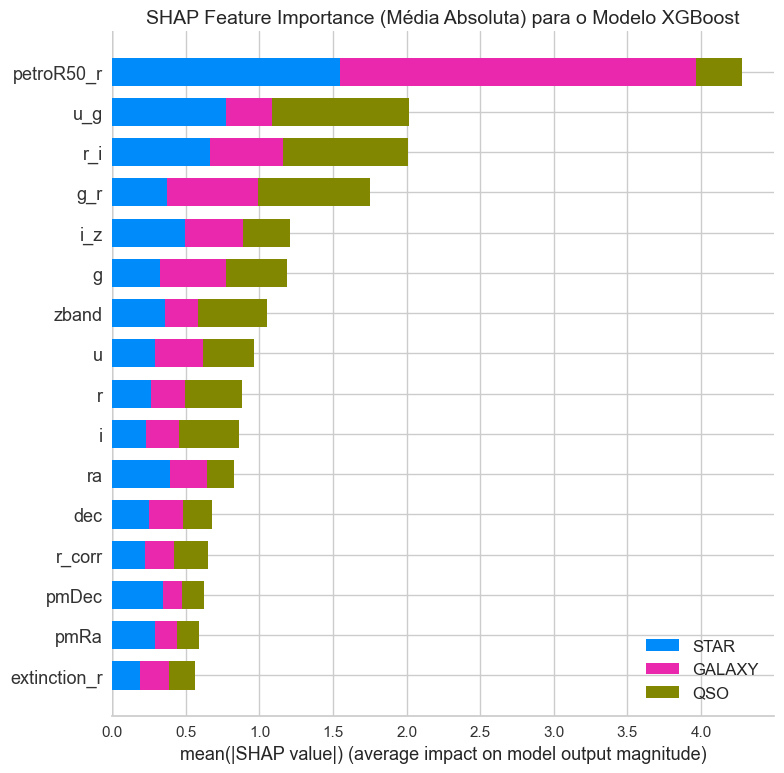

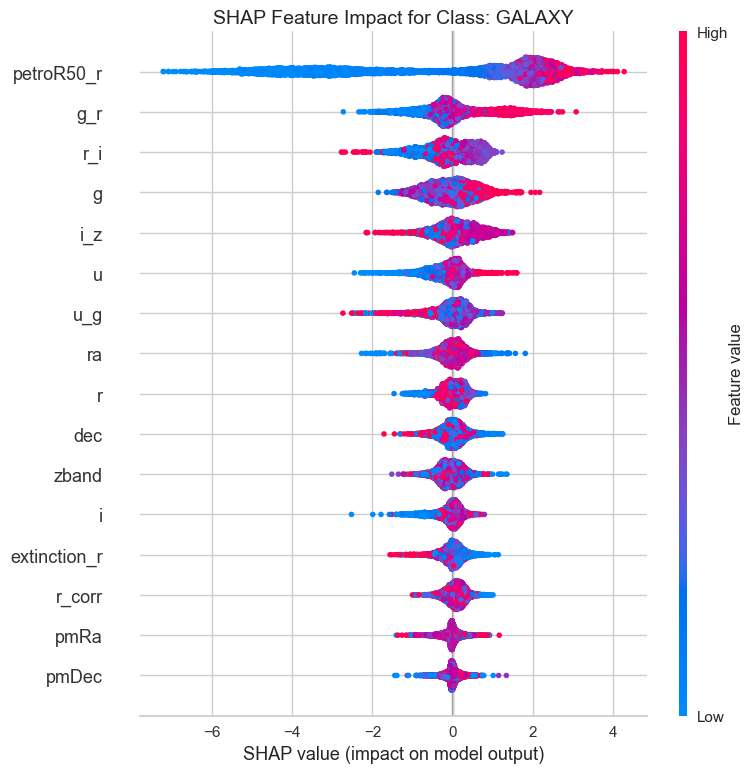

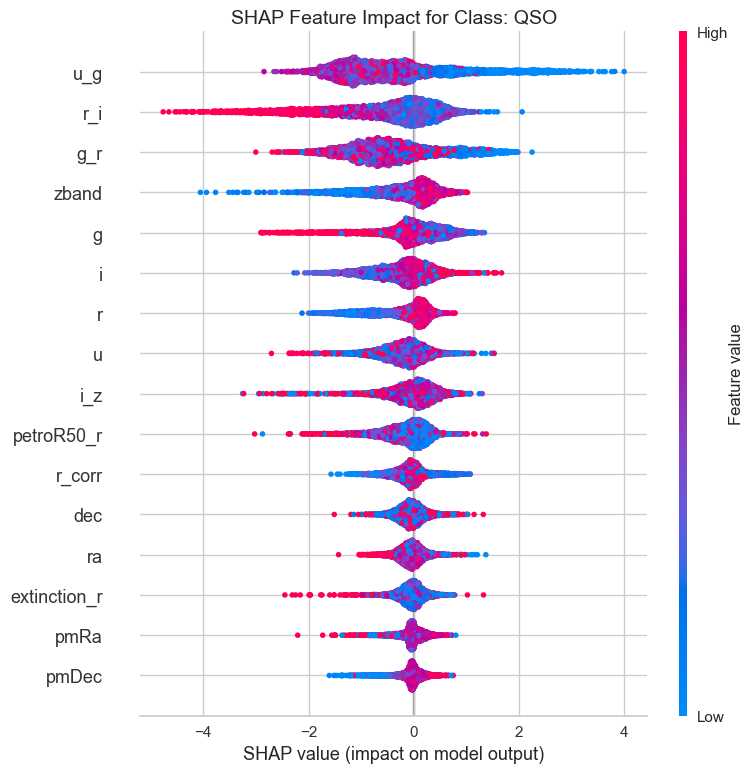

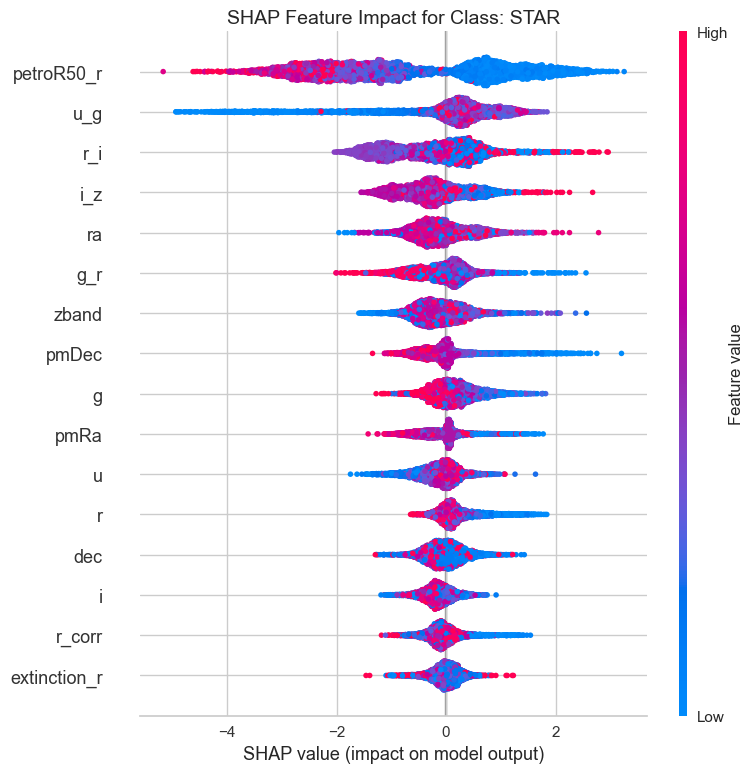

In [20]:
# Como shap_values tem shape tridimensional (samples, features, classes) devido ao resultado de classificação,
# Montamos um gráfico de barras para mostrar a importância média absoluta de cada feature considerando todas as classes,
# depois montamos um gráfico SHAP por classe para entender quais features impactam mais cada classe individualmente.


shap.summary_plot(shap_values, X_test_sample, feature_names=X.columns, class_names=le.classes_, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Média Absoluta) para o Modelo XGBoost", fontsize=14)
# Mesmo com show=False, o summary_plot do shap não funciona com subplots, então precisamos mostrar um gráfico de cada vez.
plt.tight_layout()
plt.show()

for i, class_name in enumerate(le.classes_):
    # shap_values[:, :, i] gives the SHAP values for class index i.
    shap.summary_plot(shap_values[:, :, i], X_test_sample, show=False)
    plt.title(f"SHAP Feature Impact for Class: {class_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

---

## 7. Deploy da Solução: Interface Interativa com Gradio

In [21]:
import gradio as gr

# Define the raw feature names used for input
raw_feature_names = [
    "ra", "dec", "u", "g", "r", "i", "zband", "petroR50_r", 
    "extinction_r", "pmRa", "pmDec"
]

def predict_stellar_class(ra, dec, u, g, r, i, zband, petroR50_r, extinction_r, pmRa, pmDec):
    # 1. Convert the raw input arguments into a DataFrame
    input_df = pd.DataFrame([{
        "ra": ra, "dec": dec, "u": u, "g": g, "r": r, "i": i, "zband": zband, "petroR50_r": petroR50_r,
        "extinction_r": extinction_r, "pmRa": pmRa, "pmDec": pmDec
    }])

    # 2. Calculate derived features using the raw inputs
    input_df["r_corr"] = input_df["r"] - input_df["extinction_r"]
    input_df["u_g"] = input_df["u"] - input_df["g"]
    input_df["g_r"] = input_df["g"] - input_df["r_corr"]
    input_df["r_i"] = input_df["r_corr"] - input_df["i"]
    input_df["i_z"] = input_df["i"] - input_df["zband"]

    # 3. Predict the class using the full feature set
    prediction_encoded = modelo_xgb.predict(input_df)
    
    # Decode the prediction back to the class name
    predicted_class = le.inverse_transform(prediction_encoded)[0]
    
    return predicted_class

# Calculate 1st and 99th percentile ranges to clear outliers
min_max_ranges = {}
for feature in raw_feature_names:
    percentiles = np.round(np.percentile(df_main[feature], [1, 99]), 4)
    min_max_ranges[feature] = (percentiles[0], percentiles[1])

# Create the input components using Sliders for raw features
input_components = [
    gr.Slider(
        label=name,
        minimum=min_max_ranges[name][0], 
        maximum=min_max_ranges[name][1], 
        step=0.01, # Assuming a reasonable step size for continuous features
        value=np.round(df_main[name].mean(), 4) # Set default value to the mean
    ) for name in raw_feature_names
]

# Create the Gradio Interface
iface = gr.Interface(
    fn=predict_stellar_class, 
    inputs=input_components, 
    outputs=gr.Textbox(label="Classe Predita"),
    title="Previsão de Classe Estelar (XGBoost)",
    description="Insira os 11 features físicos de um objeto celeste para prever sua classificação (ESTRELA, GALÁXIA, QSO).",
    clear_btn=None,
    flagging_mode="never"
)

# Launch the interface (This will run the local web server)
# To run this in a notebook environment, you might need to use .show() or similar methods 
# depending on the environment setup, but for a standard deployment, launch() is used.
iface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
